# FRET Biosensor Design

**BioPipelines example** — linker length optimisation for a calcium-responsive FRET biosensor (EBFP–CaM–EYFP fusion). Boltz2 predicts apo and holo structures; chromophore distances are computed and converted to FRET efficiencies.

[![Documentation](https://img.shields.io/badge/docs-readthedocs-blue)](https://biopipelines.readthedocs.io/en/latest/)
[![Preprint](https://img.shields.io/badge/preprint-bioRxiv-B31B1B)](https://www.biorxiv.org/content/10.64898/2026.03.11.711024v1)

In [ ]:
# Cell 1: Install BioPipelines and micromamba
!git clone https://github.com/locbp-uzh/biopipelines
%cd biopipelines
!pip install -e .
!wget -q https://github.com/mamba-org/micromamba-releases/releases/latest/download/micromamba-linux-64 -O /usr/local/bin/micromamba && chmod +x /usr/local/bin/micromamba
!micromamba create -f environments/biopipelines.yaml -y

Cloning into 'biopipelines'...
remote: Enumerating objects: 7526, done.
remote: Counting objects: 100% (896/896), done.
remote: Compressing objects: 100% (326/326), done.
remote: Total 7526 (delta 605), reused 744 (delta 559), pack-reused 6630 (from 1)
Receiving objects: 100% (7526/7526), 16.62 MiB | 29.30 MiB/s, done.
Resolving deltas: 100% (5760/5760), done.
/content/biopipelines
Obtaining file:///content/biopipelines
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 16.1 MB/s eta 0:00:00
  Building editable for biopipelines (pyproject.toml) ... done
  Created wheel for biopipelines: filename=biopipelines-1.1.1-0.edit

In [2]:
# Cell 2: Install tools
from biopipelines.pipeline import *
from biopipelines.boltz2 import Boltz2
from biopipelines.pymol import PyMOL

with Pipeline(project="Setup", job="InstallTools"):
    Boltz2.install()
    PyMOL.install()


Running Boltz2_installation (step 1)
=== Activating Environment ===
Requested: biopipelines
Environment: biopipelines
Location: /root/.local/share/mamba/envs/biopipelines
Python: /root/.local/share/mamba/envs/biopipelines/bin/python
Python version: Python 3.12.13
=== Installing Boltz2 ===
Using Cached Shard Index for conda-forge/linux-64                                                   ✔ Done
Using Cached Shard Index for conda-forge/noarch                                                     ✔ Done
Fetching and Parsing Packages' Shards                                                           ⧖ Starting
Fetching and Parsing Packages' Shards                                                     ✔ Done (0.1 sec)
Using Cached Shard Index for conda-forge/linux-64                                                   ✔ Done
Using Cached Shard Index for conda-forge/noarch                                                     ✔ Done
Fetching and Parsing Packages' Shards                              

## Cell 3: FRET Biosensor Pipeline

Fuses EBFP, calmodulin (CaM), and EYFP with varying GSG linker lengths.
Boltz2 predicts both apo and Ca²⁺-bound (holo) structures.
The chromophore distance is measured and converted to FRET efficiency using the Förster equation.

  Sequence EBFP: VSKGEELFTGVVPILVELDGDVNGHKFSVS... (type: protein, length: 227)

Running Sequence (step 1)
=== Activating Environment ===
Requested: biopipelines
Environment: biopipelines
Location: /root/.local/share/mamba/envs/biopipelines
Python: /root/.local/share/mamba/envs/biopipelines/bin/python
Python version: Python 3.12.13
Creating sequence files for 1 sequences
IDs: EBFP
Output folder: /content/biopipelines/outputs/Biosensor/CaFRET_001/001_Sequence
Creating sequence files for 1 sequences
Output folder: /content/biopipelines/outputs/Biosensor/CaFRET_001/001_Sequence/sequences
Created CSV: /content/biopipelines/outputs/Biosensor/CaFRET_001/001_Sequence/sequences/sequences.csv
Created FASTA: /content/biopipelines/outputs/Biosensor/CaFRET_001/001_Sequence/sequences/sequences.fasta

=== SEQUENCE SUMMARY ===
Total sequences: 1
  EBFP: VSKGEELFTGVVPILVELDGDVNGHKFSVS... (protein, 227 residues)

Sequence files created successfully
Checking outputs and creating completion status...
Req

StandardizedOutput({'plots': DataStream(name='plots', format='png', items=2, files=2, map_table=unset), 'tables': {'metadata': TableInfo(name='metadata', path='/content/biopipelines/outputs/Biosensor/CaFRET_001/011_Plot/tables/plot_metadata.csv', columns=['filename', 'type', 'title', 'x_column', 'y_column', 'data_sources'], count=2), 'fret_efficiency_by_linker_length': TableInfo(name='fret_efficiency_by_linker_length', path='/content/biopipelines/outputs/Biosensor/CaFRET_001/011_Plot/plots/fret_efficiency_by_linker_length.csv', columns=[], count=variable), 'calcium-induced_fret_change_by_linker_length': TableInfo(name='calcium-induced_fret_change_by_linker_length', path='/content/biopipelines/outputs/Biosensor/CaFRET_001/011_Plot/plots/calcium-induced_fret_change_by_linker_length.csv', columns=[], count=variable)}, 'output_folder': '/content/biopipelines/outputs/Biosensor/CaFRET_001/011_Plot'})
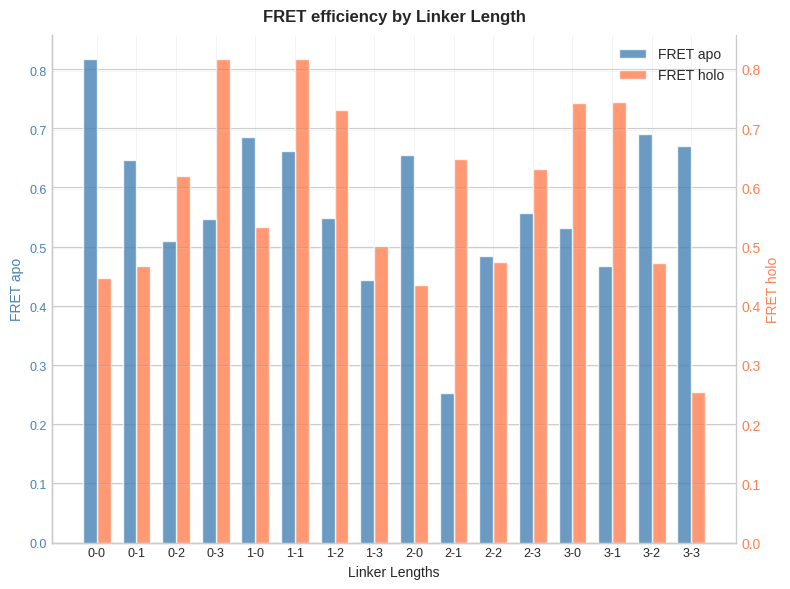
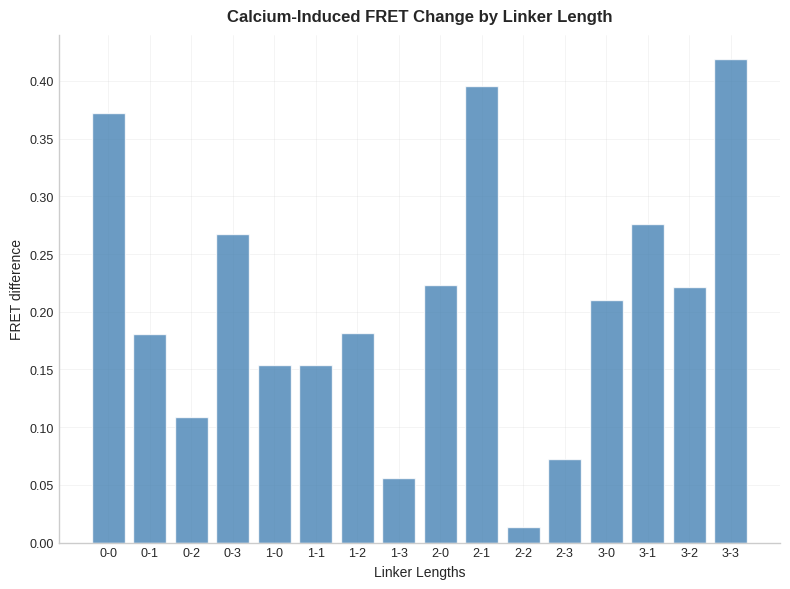

In [3]:
# Cell 3: Pipeline
from biopipelines.pipeline import *
from biopipelines.fuse import Fuse
from biopipelines.boltz2 import Boltz2
from biopipelines.distance import Distance
from biopipelines.panda import Panda
from biopipelines.plot import Plot

with Pipeline(project="Biosensor", job="CaFRET"):
    donor = Sequence("VSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLTHGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNFNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAA",
                     ids="EBFP")
    acceptor = Sequence("VSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFGYGLQCFARYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSYQSALSKDPNEKRDHMVLLEFVTAA",
                        ids="EYFP")
    cam = Sequence("ADQLTEEQIAEFKEAFSLFDKDGDGTITTKELGTVMRSLGQNPTEAELQDMINEVDADGNGTIDFPEFLTMMARKMKDTDSEEEIREAFRVFDKDGNGYISAAELRHVMTNLGEKLTDEEVDEMIREADIDGDGQVNYEEFVQMMTAK", ids="CaM")

    fusions = Fuse(sequences=[donor, cam, acceptor],
                   name="CaFRET",
                   linker="GSG",
                   linker_lengths=["0-3", "0-3"])

    apo = Boltz2(proteins=fusions)

    calcium = Ligand("CA")
    holo = Boltz2(proteins=fusions,
                  ligands=Bundle(calcium, calcium, calcium, calcium),
                  msas=apo)

    dist_apo = Distance(structures=apo,
                        residue=["66", "-173"],
                        metric_name="FRET_distance_apo")
    dist_holo = Distance(structures=holo,
                         residue=["66", "-173"],
                         metric_name="FRET_distance_holo")

    R0 = 35.4  # Forster radius for EBFP-EYFP pair (Angstrom), assumes kappa2 = 2/3
    derived_metrics = {"FRET_E_apo": f"1 / (1 + (FRET_distance_apo / {R0}) ** 6)",
                       "FRET_E_holo": f"1 / (1 + (FRET_distance_holo / {R0}) ** 6)",
                       "delta_FRET": "abs(FRET_E_holo - FRET_E_apo)"}

    analysis = Panda(tables=[fusions.tables.sequences,
                              dist_apo.tables.distances,
                              dist_holo.tables.distances],
                     operations=[Panda.merge(),
                                  Panda.calculate(derived_metrics)])

    plots = Plot(Plot.Bar(data=analysis.tables.result,
                  title="FRET efficiency by Linker Length",
                  x="lengths",
                  y="FRET_E_apo",
                  y_right="FRET_E_holo",
                  xlabel="Linker Lengths",
                  ylabel="FRET apo",
                  ylabel_right="FRET holo"),
         Plot.Bar(data=analysis.tables.result,
                  title="Calcium-Induced FRET Change by Linker Length",
                  x="lengths",
                  y="delta_FRET",
                  xlabel="Linker Lengths",
                  ylabel="FRET difference"))
plots